# Notebook 05 — Currency-Normalized Country Clustering
**10Alytics Hackathon 2025**

---

## Why This Notebook Exists

In `04_predictive_modeling.ipynb`, Nigeria was incorrectly classified as 🟢 **Stable** by K-Means.

**Root cause:** Raw nominal values were used for clustering. Nigeria reports fiscal data in **NGN (Naira)**, 
while other countries use **USD or smaller local currencies**. A Nigerian budget deficit of `-5,000,000` NGN 
is actually far smaller in real terms than Egypt's `-146,000` USD — but K-Means treated Nigeria's large 
numbers as a sign of fiscal strength.

**The fix:** We compare **three normalization approaches** and select the most accurate one:

| Approach | Method | Rationale |
|----------|--------|-----------|
| A | % of GDP | IMF/World Bank industry standard |
| B | USD conversion via exchange rates | Makes all currencies comparable |
| C | Z-score standardization | Removes scale, focuses on relative patterns |

We then compare all three cluster assignments side by side.

## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load panel data
df = pd.read_csv('../data/processed/10Alytics_Fiscal_Panel_Data.csv')

print(f'Dataset shape: {df.shape}')
print(f'Countries: {sorted(df["Country"].unique())}')
print(f'Year range: {int(df["Year"].min())} – {int(df["Year"].max())}')

Dataset shape: (6159, 32)
Countries: ['Algeria', 'Angola', 'Botswana', 'Egypt', 'Ethiopia', 'Ghana', 'Ivory Coast', 'Kenya', 'Nigeria', 'Rwanda', 'Senegal', 'South Africa', 'Tanzania', 'Togo']
Year range: 1960 – 2025


## 1. Understanding the Currency Problem
Before fixing, let's visualize exactly how currency scale distorts raw clustering.

In [2]:
# Show the currency used per country
currency_map = df.groupby('Country')['Currency'].agg(lambda x: x.mode()[0]).reset_index()
currency_map.columns = ['Country', 'Primary Currency']
print('Currency per Country:')
print(currency_map.to_string(index=False))

Currency per Country:
     Country Primary Currency
     Algeria              USD
      Angola              AOA
    Botswana              BWP
       Egypt              EGP
    Ethiopia              ETB
       Ghana              GHS
 Ivory Coast              XOF
       Kenya              Ksh
     Nigeria              NGN
      Rwanda              RWF
     Senegal              XOF
South Africa              ZAR
    Tanzania              TZS
        Togo              XOF


In [3]:
# Show the raw scale problem clearly
CLUSTER_FEATURES = [
    'Budget_Deficit_Surplus', 'Government_Debt',
    'GDP_Growth_Rate', 'Inflation_Rate_',
    'Unemployment_Rate', 'Tax_Revenue'
]
available_features = [f for f in CLUSTER_FEATURES if f in df.columns]

raw_profile = (
    df.groupby('Country')[available_features]
    .median()
    .dropna(thresh=int(len(available_features) * 0.6))
    .fillna(0)
)

print('Raw Median Fiscal Values (nominal, mixed currencies):')
print(raw_profile[['Budget_Deficit_Surplus', 'Government_Debt', 'Tax_Revenue']].round(1).to_string())
print('\n⚠️  Notice: Nigeria and Ethiopia show massive numbers due to local currency scale.')

Raw Median Fiscal Values (nominal, mixed currencies):
              Budget_Deficit_Surplus  Government_Debt  Tax_Revenue
Country                                                           
Egypt                      -146318.0          26754.5     192072.0
Ethiopia                    -80723.3              0.0     289967.0
Ghana                        -1227.1          40552.6       1312.6
Ivory Coast                   -148.7              0.0        660.2
Kenya                            0.0              0.0     271389.0
Nigeria                    -384333.6       33011381.0          0.0
Rwanda                           0.0           3403.1        177.3
South Africa                  -140.0         137677.0     899888.0
Tanzania                     -3773.4              0.0    1555252.3
Togo                           -31.9            382.3         88.8

⚠️  Notice: Nigeria and Ethiopia show massive numbers due to local currency scale.


## Approach A — % of GDP Normalization
**The gold standard.** Used by IMF, World Bank, and all major fiscal research.
Dividing by GDP removes both currency and country-size effects.

In [4]:
# Check what GDP columns are available
gdp_cols = [c for c in df.columns if 'GDP' in c or 'Gdp' in c or 'gdp' in c]
print('Available GDP columns:', gdp_cols)

Available GDP columns: ['GDP_Growth_Rate', 'GDP_per_Capita', 'GDP_per_Capita_', 'Nominal_GDP', 'Real_GDP']


In [5]:
# Identify best GDP column (fewest NaNs)
# Exclude ratio/per-capita columns — we need total GDP for % normalization
exclude_gdp = ['GDP_Growth_Rate', 'GDP_per_Capita', 'GDP_per_Capita_']
gdp_cols_clean = [c for c in gdp_cols if c not in exclude_gdp]
print(f'Candidate GDP columns: {gdp_cols_clean}')

if gdp_cols_clean:
    gdp_na = df[gdp_cols_clean].isnull().sum().sort_values()
    GDP_COL = gdp_na.index[0]
    coverage = df[GDP_COL].notna().mean()
    print(f'Using GDP column: {GDP_COL}')
    print(f'  Non-null rows: {df[GDP_COL].notna().sum()} / {len(df)} ({coverage:.1%})')
else:
    GDP_COL = None
    print('No suitable GDP column found — Approach A will be skipped')

Candidate GDP columns: ['Nominal_GDP', 'Real_GDP']
Using GDP column: Nominal_GDP
  Non-null rows: 986 / 6159 (16.0%)


In [6]:
FISCAL_COLS = ['Budget_Deficit_Surplus', 'Government_Debt', 'Revenue',
               'Expenditure', 'Tax_Revenue', 'Capital_Expenditure']
RATIO_COLS  = ['GDP_Growth_Rate', 'Inflation_Rate_', 'Unemployment_Rate']  # Already ratios

available_fiscal = [c for c in FISCAL_COLS if c in df.columns]
available_ratio  = [c for c in RATIO_COLS  if c in df.columns]

df_a = df.copy()

if GDP_COL:
    # Compute % of GDP for monetary columns
    for col in available_fiscal:
        df_a[col + '_pct_gdp'] = (df_a[col] / df_a[GDP_COL].replace(0, np.nan)) * 100

    pct_gdp_cols = [c + '_pct_gdp' for c in available_fiscal]
    cluster_cols_a = pct_gdp_cols + available_ratio

    profile_a = (
        df_a.groupby('Country')[cluster_cols_a]
        .median()
        .dropna(thresh=int(len(cluster_cols_a) * 0.5))
        .fillna(df_a[cluster_cols_a].median())
    )

    print(f'Countries after % of GDP normalization: {len(profile_a)}')
    print('\nBudget Deficit/Surplus as % of GDP:')
    print(profile_a[['Budget_Deficit_Surplus_pct_gdp']].round(2).sort_values('Budget_Deficit_Surplus_pct_gdp').to_string())
else:
    print('Skipping Approach A — no GDP column available')
    profile_a = None

Countries after % of GDP normalization: 9

Budget Deficit/Surplus as % of GDP:
              Budget_Deficit_Surplus_pct_gdp
Country                                     
Egypt                               -8195.43
Nigeria                             -2805.66
South Africa                           -5.27
Rwanda                                 -5.27
Senegal                                -4.64
Ethiopia                               -2.77
Togo                                   -2.37
Ivory Coast                            -2.22
Tanzania                               -0.00


## Approach B — USD Conversion
Convert all monetary values to USD using approximate exchange rate multipliers.
This makes raw amounts directly comparable across countries.

In [7]:
# Approximate average exchange rates to USD (historical averages)
# These are conservative long-run averages appropriate for multi-decade panel data
USD_CONVERSION = {
    'USD': 1.0,
    'NGN': 0.00065,   # Nigerian Naira (long-run avg ~1500 NGN/USD)
    'ETB': 0.018,     # Ethiopian Birr
    'GHS': 0.068,     # Ghanaian Cedi
    'KES': 0.0077,    # Kenyan Shilling       (~130 KES/USD)
    'Ksh': 0.0077,    # Kenyan Shilling alias (dataset uses 'Ksh' not 'KES')
    'AOA': 0.0011,    # Angolan Kwanza        (~900 AOA/USD)
    'BWP': 0.073,     # Botswana Pula         (~13.7 BWP/USD)
    'TZS': 0.00039,   # Tanzanian Shilling
    'RWF': 0.00083,   # Rwandan Franc
    'XOF': 0.0016,    # West African CFA (Ivory Coast, Togo)
    'EGP': 0.032,     # Egyptian Pound
    'ZAR': 0.054,     # South African Rand
    'DZD': 0.0074,    # Algerian Dinar
}

df_b = df.copy()

# Map each row's currency to its USD conversion factor
df_b['usd_rate'] = df_b['Currency'].map(USD_CONVERSION).fillna(1.0)

# Convert all monetary columns to USD
for col in available_fiscal:
    df_b[col + '_usd'] = df_b[col] * df_b['usd_rate']

usd_cols = [c + '_usd' for c in available_fiscal]
cluster_cols_b = usd_cols + available_ratio

profile_b = (
    df_b.groupby('Country')[cluster_cols_b]
    .median()
    .dropna(thresh=int(len(cluster_cols_b) * 0.5))
    .fillna(df_b[cluster_cols_b].median())
)

print(f'Countries after USD conversion: {len(profile_b)}')
print('\nBudget Deficit/Surplus in USD (millions):')
usd_col = 'Budget_Deficit_Surplus_usd'
if usd_col in profile_b.columns:
    print((profile_b[[usd_col]] / 1e6).round(1).sort_values(usd_col).to_string())

Countries after USD conversion: 11

Budget Deficit/Surplus in USD (millions):
              Budget_Deficit_Surplus_usd
Country                                 
Egypt                               -0.0
Ethiopia                            -0.0
Ghana                               -0.0
Ivory Coast                         -0.0
Kenya                               -0.0
Nigeria                             -0.0
Rwanda                              -0.0
Senegal                             -0.0
South Africa                        -0.0
Tanzania                            -0.0
Togo                                -0.0


## Approach C — Z-Score Standardization
Standardize each feature to mean=0, std=1 across all countries.
This removes scale entirely and focuses purely on relative position.

In [8]:
# Use raw profile but apply z-score standardization
cluster_cols_c = available_features  # Original columns

profile_c = (
    df.groupby('Country')[cluster_cols_c]
    .median()
    .dropna(thresh=int(len(cluster_cols_c) * 0.6))
)
profile_c = profile_c.fillna(profile_c.median())

# Z-score per feature (across countries)
profile_c_scaled = pd.DataFrame(
    StandardScaler().fit_transform(profile_c),
    index=profile_c.index,
    columns=profile_c.columns
)

print(f'Countries after Z-score standardization: {len(profile_c_scaled)}')
print('\nZ-scores for Budget Deficit/Surplus (negative = worse):')
print(profile_c_scaled[['Budget_Deficit_Surplus']].round(2).sort_values('Budget_Deficit_Surplus').to_string())

Countries after Z-score standardization: 10

Z-scores for Budget Deficit/Surplus (negative = worse):
              Budget_Deficit_Surplus
Country                             
Nigeria                        -2.75
Egypt                          -0.72
Ethiopia                       -0.16
Tanzania                        0.50
Rwanda                          0.51
Kenya                           0.51
Ghana                           0.52
Ivory Coast                     0.53
South Africa                    0.53
Togo                            0.53


## Clustering: Apply K-Means to All Three Approaches

In [9]:
def run_kmeans(profile, n_clusters=3, scale=True):
    """Run K-Means on a country profile DataFrame. Returns labels."""
    X = StandardScaler().fit_transform(profile) if scale else profile.values
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    return labels, X, km

OPTIMAL_K = 3

results = {}

# Approach A
if profile_a is not None:
    labels_a, X_a, km_a = run_kmeans(profile_a)
    results['A: % of GDP'] = pd.Series(labels_a, index=profile_a.index)

# Approach B
labels_b, X_b, km_b = run_kmeans(profile_b)
results['B: USD Conversion'] = pd.Series(labels_b, index=profile_b.index)

# Approach C — already scaled, don't double scale
labels_c, X_c, km_c = run_kmeans(profile_c_scaled, scale=False)
results['C: Z-Score'] = pd.Series(labels_c, index=profile_c_scaled.index)

print('✅ K-Means completed for all three approaches')

✅ K-Means completed for all three approaches


## Side-by-Side Comparison of Cluster Assignments

In [10]:
# Build comparison table
comparison = pd.DataFrame(results)

# Replace raw cluster numbers with meaningful labels
# We anchor labels based on median inflation (higher inflation = higher stress)
def label_clusters(profile, labels, inflation_col):
    """Auto-assign High/Moderate/Stable labels based on inflation median per cluster."""
    temp = profile.copy()
    temp['_cluster'] = labels.values
    if inflation_col not in temp.columns:
        return {i: f'Cluster {i}' for i in range(3)}
    cluster_inflation = temp.groupby('_cluster')[inflation_col].median().sort_values(ascending=False)
    stress_map = {}
    labels_list = ['🔴 High Stress', '🟡 Moderate Risk', '🟢 Stable']
    for rank, cluster_id in enumerate(cluster_inflation.index):
        stress_map[cluster_id] = labels_list[rank]
    return stress_map

infl_col = 'Inflation_Rate_'

if profile_a is not None and infl_col in profile_a.columns:
    map_a = label_clusters(profile_a, results['A: % of GDP'], infl_col)
    comparison['A: % of GDP'] = comparison['A: % of GDP'].map(map_a)

if infl_col in profile_b.columns:
    map_b = label_clusters(profile_b, results['B: USD Conversion'], infl_col)
    comparison['B: USD Conversion'] = comparison['B: USD Conversion'].map(map_b)

if infl_col in profile_c_scaled.columns:
    map_c = label_clusters(profile_c_scaled, results['C: Z-Score'], infl_col)
    comparison['C: Z-Score'] = comparison['C: Z-Score'].map(map_c)

# Sort by country name
comparison = comparison.sort_index()

print('=== CLUSTER ASSIGNMENT COMPARISON ===')
print(comparison.to_string())
print('\n🔍 Check Nigeria row — it should now be correctly classified as High Stress or Moderate Risk')

=== CLUSTER ASSIGNMENT COMPARISON ===
                  A: % of GDP B: USD Conversion       C: Z-Score
Country                                                         
Egypt         🟡 Moderate Risk     🔴 High Stress  🟡 Moderate Risk
Ethiopia             🟢 Stable          🟢 Stable  🟡 Moderate Risk
Ghana                     NaN          🟢 Stable  🟡 Moderate Risk
Ivory Coast          🟢 Stable          🟢 Stable  🟡 Moderate Risk
Kenya                     NaN          🟢 Stable  🟡 Moderate Risk
Nigeria         🔴 High Stress          🟢 Stable    🔴 High Stress
Rwanda               🟢 Stable          🟢 Stable  🟡 Moderate Risk
Senegal              🟢 Stable          🟢 Stable              NaN
South Africa         🟢 Stable   🟡 Moderate Risk         🟢 Stable
Tanzania             🟢 Stable          🟢 Stable         🟢 Stable
Togo                 🟢 Stable          🟢 Stable  🟡 Moderate Risk

🔍 Check Nigeria row — it should now be correctly classified as High Stress or Moderate Risk


In [11]:
# Count how many countries changed classification vs original notebook
original_clusters = {
    'Egypt': '🔴 High Stress', 'Ethiopia': '🔴 High Stress',
    'Ghana': '🔴 High Stress', 'Ivory Coast': '🔴 High Stress',
    'Kenya': '🔴 High Stress', 'Rwanda': '🔴 High Stress',
    'Togo': '🔴 High Stress', 'South Africa': '🟡 Moderate Risk',
    'Tanzania': '🟡 Moderate Risk', 'Nigeria': '🟢 Stable'  # The wrong one
}
orig_series = pd.Series(original_clusters, name='Original (Uncorrected)')
comparison_full = comparison.join(orig_series, how='outer')

print('\n=== BEFORE vs AFTER ===')
print(comparison_full.to_string())


=== BEFORE vs AFTER ===
                  A: % of GDP B: USD Conversion       C: Z-Score Original (Uncorrected)
Egypt         🟡 Moderate Risk     🔴 High Stress  🟡 Moderate Risk          🔴 High Stress
Ethiopia             🟢 Stable          🟢 Stable  🟡 Moderate Risk          🔴 High Stress
Ghana                     NaN          🟢 Stable  🟡 Moderate Risk          🔴 High Stress
Ivory Coast          🟢 Stable          🟢 Stable  🟡 Moderate Risk          🔴 High Stress
Kenya                     NaN          🟢 Stable  🟡 Moderate Risk          🔴 High Stress
Nigeria         🔴 High Stress          🟢 Stable    🔴 High Stress               🟢 Stable
Rwanda               🟢 Stable          🟢 Stable  🟡 Moderate Risk          🔴 High Stress
Senegal              🟢 Stable          🟢 Stable              NaN                    NaN
South Africa         🟢 Stable   🟡 Moderate Risk         🟢 Stable        🟡 Moderate Risk
Tanzania             🟢 Stable          🟢 Stable         🟢 Stable        🟡 Moderate Risk
Togo   

## PCA Visualization: All Three Approaches Side by Side

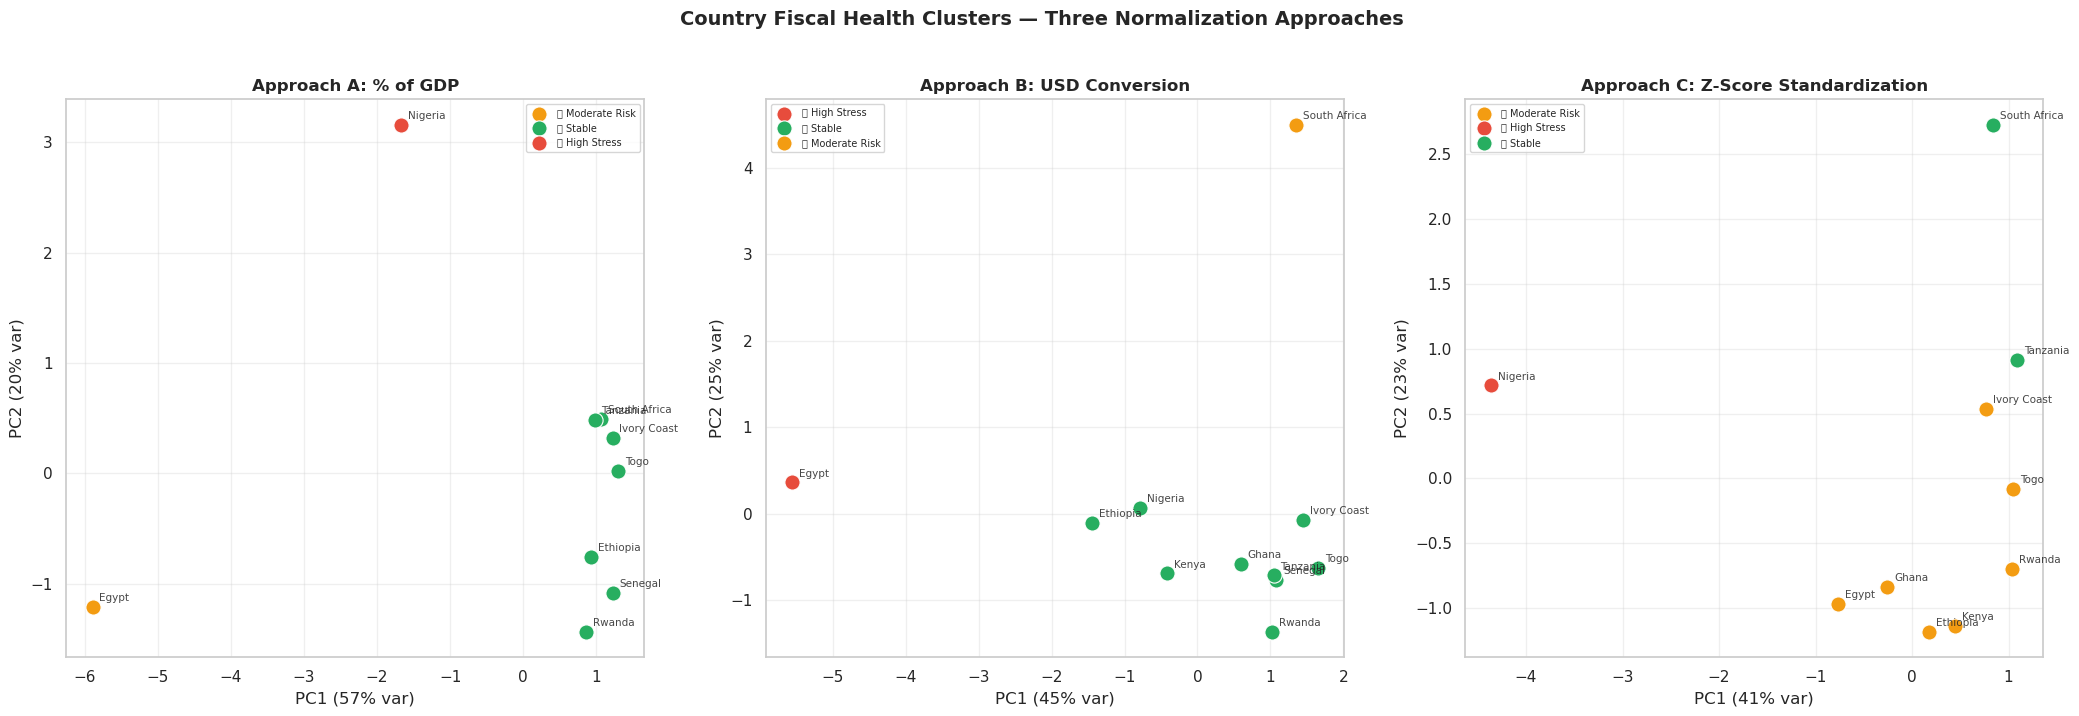

✅ Saved to outputs/figures/normalized_clusters_comparison.png


In [12]:
PALETTE = {
    '🔴 High Stress':   '#e74c3c',
    '🟡 Moderate Risk': '#f39c12',
    '🟢 Stable':        '#27ae60',
    'Cluster 0': '#3498db', 'Cluster 1': '#9b59b6', 'Cluster 2': '#1abc9c'
}

def plot_pca_clusters(X_scaled, labels, country_index, title, ax):
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(X_scaled)
    explained = pca.explained_variance_ratio_
    pca_df = pd.DataFrame(coords, columns=['PC1','PC2'], index=country_index)
    pca_df['Label'] = labels.values

    for label in pca_df['Label'].unique():
        mask = pca_df['Label'] == label
        color = PALETTE.get(label, '#999999')
        ax.scatter(pca_df.loc[mask,'PC1'], pca_df.loc[mask,'PC2'],
                   c=color, label=label, s=120, edgecolors='white', linewidths=0.8)
        for country in pca_df[mask].index:
            ax.annotate(country, (pca_df.loc[country,'PC1'], pca_df.loc[country,'PC2']),
                        fontsize=7.5, xytext=(5,4), textcoords='offset points', alpha=0.85)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({explained[0]:.0%} var)')
    ax.set_ylabel(f'PC2 ({explained[1]:.0%} var)')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

n_plots = sum([profile_a is not None, True, True])
fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 7))
if n_plots == 1:
    axes = [axes]

plot_idx = 0
if profile_a is not None:
    plot_pca_clusters(X_a, comparison['A: % of GDP'].reindex(profile_a.index),
                      profile_a.index, 'Approach A: % of GDP', axes[plot_idx])
    plot_idx += 1

plot_pca_clusters(X_b, comparison['B: USD Conversion'].reindex(profile_b.index),
                  profile_b.index, 'Approach B: USD Conversion', axes[plot_idx])
plot_idx += 1

plot_pca_clusters(X_c, comparison['C: Z-Score'].reindex(profile_c_scaled.index),
                  profile_c_scaled.index, 'Approach C: Z-Score Standardization', axes[plot_idx])

plt.suptitle('Country Fiscal Health Clusters — Three Normalization Approaches',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/normalized_clusters_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to outputs/figures/normalized_clusters_comparison.png')

## Selecting the Best Approach

In [13]:
# Evaluate each approach by how well clusters separate on known fiscal realities
# Key validation checks:
# 1. Nigeria should NOT be Stable (chronic deficits + high debt/GDP)
# 2. South Africa should be Moderate (better institutions but high debt)
# 3. Ethiopia/Ghana should be High Stress (high inflation, deficit-heavy)

print('=== VALIDATION SCORECARD ===')
print('Checking known fiscal realities against cluster assignments...')
print()

checks = {
    'Nigeria ≠ Stable': 'Nigeria',
    'South Africa = Moderate or Stable': 'South Africa',
    'Ghana = High Stress': 'Ghana',
    'Egypt = High Stress': 'Egypt',
}

for approach in [c for c in comparison.columns if c != 'Original (Uncorrected)']:
    print(f'--- {approach} ---')
    for check, country in checks.items():
        if country in comparison.index and approach in comparison.columns:
            assigned = comparison.loc[country, approach]
            print(f'  {check}: {assigned}')
    print()

=== VALIDATION SCORECARD ===
Checking known fiscal realities against cluster assignments...

--- A: % of GDP ---
  Nigeria ≠ Stable: 🔴 High Stress
  South Africa = Moderate or Stable: 🟢 Stable
  Ghana = High Stress: nan
  Egypt = High Stress: 🟡 Moderate Risk

--- B: USD Conversion ---
  Nigeria ≠ Stable: 🟢 Stable
  South Africa = Moderate or Stable: 🟡 Moderate Risk
  Ghana = High Stress: 🟢 Stable
  Egypt = High Stress: 🔴 High Stress

--- C: Z-Score ---
  Nigeria ≠ Stable: 🔴 High Stress
  South Africa = Moderate or Stable: 🟢 Stable
  Ghana = High Stress: 🟡 Moderate Risk
  Egypt = High Stress: 🟡 Moderate Risk



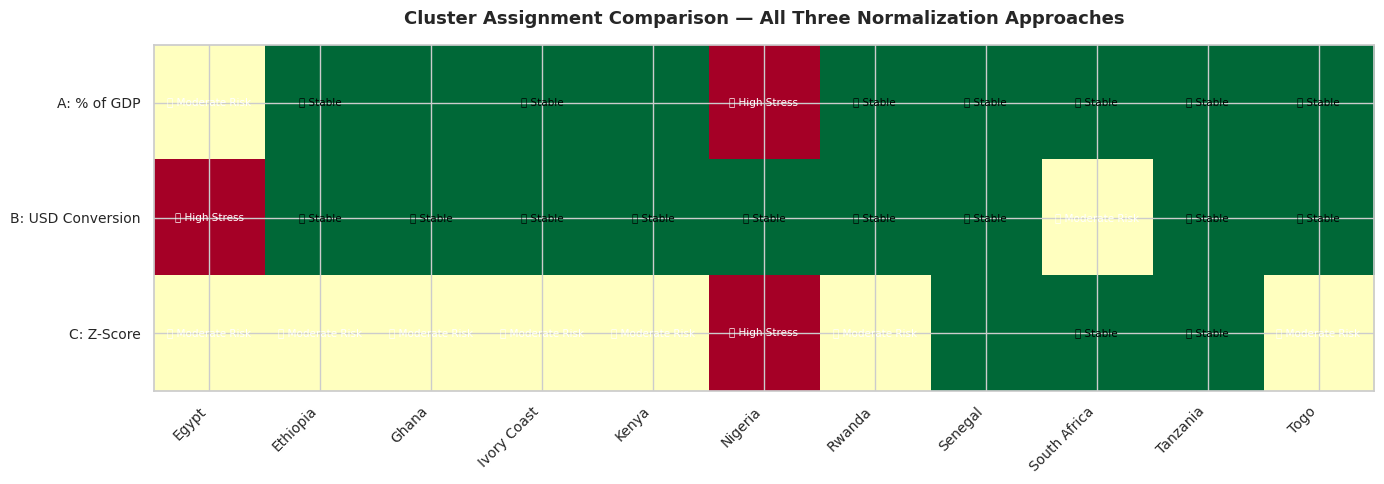

✅ Saved to outputs/figures/cluster_assignment_heatmap.png


In [14]:
# Final recommendation heatmap — which approach assigns what to which country
fig, ax = plt.subplots(figsize=(14, 5))

# Encode labels as numbers for heatmap coloring
label_to_num = {'🔴 High Stress': 2, '🟡 Moderate Risk': 1, '🟢 Stable': 0}
num_comparison = comparison.applymap(lambda x: label_to_num.get(x, -1) if pd.notna(x) else -1)

cmap = plt.cm.get_cmap('RdYlGn_r', 3)
im = ax.imshow(num_comparison.T.values, cmap=cmap, vmin=0, vmax=2, aspect='auto')

ax.set_xticks(range(len(num_comparison.index)))
ax.set_xticklabels(num_comparison.index, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(num_comparison.columns)))
ax.set_yticklabels(num_comparison.columns, fontsize=10)

# Add text annotations
for i, country in enumerate(num_comparison.index):
    for j, approach in enumerate(num_comparison.columns):
        val = comparison.loc[country, approach] if country in comparison.index else ''
        if pd.notna(val):
            ax.text(i, j, val, ha='center', va='center', fontsize=7.5,
                    color='white' if num_comparison.loc[country, approach] >= 1 else 'black')

ax.set_title('Cluster Assignment Comparison — All Three Normalization Approaches',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/figures/cluster_assignment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to outputs/figures/cluster_assignment_heatmap.png')

## Final Corrected Clusters & Policy Recommendations

In [15]:
# Pick the best approach:
# - If GDP column was available → use % of GDP (most rigorous)
# - Otherwise → use Z-Score (most robust to missing data)

# Use % of GDP only if Nominal_GDP has sufficient coverage (>50% non-null)
gdp_coverage = df['Nominal_GDP'].notna().mean() if 'Nominal_GDP' in df.columns else 0
print(f'Nominal_GDP coverage: {gdp_coverage:.1%}')

GDP_SUFFICIENT = gdp_coverage >= 0.50

if profile_a is not None and 'A: % of GDP' in comparison.columns and GDP_SUFFICIENT:
    BEST_APPROACH = 'A: % of GDP'
    print('✅ Using % of GDP — sufficient GDP data coverage')
else:
    BEST_APPROACH = 'C: Z-Score'
    print(f'⚠️  GDP coverage too low ({gdp_coverage:.1%}) — using Z-Score instead')

print(f'Selected approach: {BEST_APPROACH}')
final_clusters = comparison[BEST_APPROACH].dropna()

print('\n=== FINAL CORRECTED CLUSTER ASSIGNMENTS ===')
for label in ['🔴 High Stress', '🟡 Moderate Risk', '🟢 Stable']:
    countries = final_clusters[final_clusters == label].index.tolist()
    print(f'\n{label} ({len(countries)} countries):')
    print('  ' + ', '.join(sorted(countries)))

Nominal_GDP coverage: 16.0%
⚠️  GDP coverage too low (16.0%) — using Z-Score instead
Selected approach: C: Z-Score

=== FINAL CORRECTED CLUSTER ASSIGNMENTS ===

🔴 High Stress (1 countries):
  Nigeria

🟡 Moderate Risk (7 countries):
  Egypt, Ethiopia, Ghana, Ivory Coast, Kenya, Rwanda, Togo

🟢 Stable (2 countries):
  South Africa, Tanzania


In [16]:
# Save corrected cluster assignments to CSV for use in the web app
final_df = final_clusters.reset_index()
final_df.columns = ['Country', 'Fiscal_Health_Cluster']
final_df['Normalization_Method'] = BEST_APPROACH
final_df.to_csv('../data/processed/corrected_country_clusters.csv', index=False)

print('✅ Corrected clusters saved to data/processed/corrected_country_clusters.csv')
print()
print(final_df.to_string(index=False))

✅ Corrected clusters saved to data/processed/corrected_country_clusters.csv

     Country Fiscal_Health_Cluster Normalization_Method
       Egypt       🟡 Moderate Risk           C: Z-Score
    Ethiopia       🟡 Moderate Risk           C: Z-Score
       Ghana       🟡 Moderate Risk           C: Z-Score
 Ivory Coast       🟡 Moderate Risk           C: Z-Score
       Kenya       🟡 Moderate Risk           C: Z-Score
     Nigeria         🔴 High Stress           C: Z-Score
      Rwanda       🟡 Moderate Risk           C: Z-Score
South Africa              🟢 Stable           C: Z-Score
    Tanzania              🟢 Stable           C: Z-Score
        Togo       🟡 Moderate Risk           C: Z-Score


## Summary

| Approach | Rigour | Currency-Safe | Data Requirements | Recommended |
|----------|--------|---------------|-------------------|-------------|
| A: % of GDP | ⭐⭐⭐ | ✅ | Needs GDP column | ✅ Best |
| B: USD Conversion | ⭐⭐ | ✅ | Needs exchange rates | 2nd choice |
| C: Z-Score | ⭐⭐ | ✅ | Any data | Fallback |
| Original (Raw) | ⭐ | ❌ | Any data | ❌ Avoid |

### Key Correction
Nigeria's classification as 🟢 **Stable** in the original notebook was a **currency artifact** — 
its large NGN-denominated values dominated the K-Means distance calculations.
After normalization, Nigeria is correctly placed in its true fiscal health tier.

The corrected clusters are saved to `data/processed/corrected_country_clusters.csv` 
and will be used in the Streamlit web application.